# Count the number of colocalization points in the Mediterranean sea
## What is done here ?
- select the drifters points under the swaths for each cycle considering drifters points for which it is the nearest swot image (one cycle every 23h50 approximately, e.g drifters in the $\pm$ 12h25 before and after the swot image)
- compute the minimum/maximum time gap for each swot image/cycle (will depend on the dt of the regular grid)
- plot the evolution of the number of drifter segment/colocalization under each swath depending on the cycle

## Results ?
- for dt = 10min : 13 829 trajectories segments, 2 068 716 point in total
- some cycle are not available :
    - swath 3 : 498, 526-528, 566, 572
    - swath 16 : 480, 508, 513, 526-528, 534

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from rasterio.transform import Affine

import pynsitu as pyn

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(


_______
# Select under swath drifters

In [2]:
dfs = browse_swot_250().reset_index()
dfs

,day,pass_number,cycle_number,file,time,start_time_cut,end_time_cut
0,2023-04-01,3,478,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-04-01 23:42:32.696536000,2023-04-01 11:47:13.760762624,2023-04-02 11:37:51.561104544
1,2023-04-02,3,479,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-04-02 23:33:10.425673088,2023-04-02 11:37:51.561104544,2023-04-03 11:28:29.307429408
2,2023-04-03,3,480,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-04-03 23:23:48.189185728,2023-04-03 11:28:29.307429408,2023-04-04 11:19:07.046608544
3,2023-04-04,3,481,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-04-04 23:14:25.904031360,2023-04-04 11:19:07.046608544,2023-04-05 11:09:44.780262144
4,2023-04-05,3,482,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-04-05 23:05:03.656492928,2023-04-05 11:09:44.780262144,2023-04-06 11:00:22.763027360
...,...,...,...,...,...,...,...
182,2023-07-05,16,573,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-07-05 19:33:50.331633280,2023-07-05 07:38:31.368841152,2023-07-06 07:29:09.302501440
183,2023-07-06,16,574,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-07-06 19:24:28.273369600,2023-07-06 07:29:09.302501440,2023-07-07 07:19:47.209324384
184,2023-07-07,16,575,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-07-07 19:15:06.145279168,2023-07-07 07:19:47.209324384,2023-07-08 07:10:25.074586176
185,2023-07-08,16,576,/home/datawork-lops-osi/aponte/swot/cswot/swot...,2023-07-08 19:05:44.003893184,2023-07-08 07:10:25.074586176,2023-07-09 07:01:02.936174400


In [3]:
drifters_sources = 'all_med_variational_10min_v0.nc'
dr = xr.open_dataset(os.path.join(drifters_dir,'L2', 'all_med_variational_10min_v0.nc'))
dr_key = dr[['cruise_id', 'drifter_type']]
dr = dr.where(dr.gap_mask==1)

def sel_drifters(swath, cycle):
    dfs_ = dfs.where((dfs.pass_number==swath)&(dfs.cycle_number==cycle)).dropna()
    dss = xr.open_dataset(dfs.where((dfs.pass_number==swath)&(dfs.cycle_number==cycle)).dropna().file.values[0])
    
    #time
    dr_ = dr.sel(datetime = slice(pd.to_datetime(dfs_.start_time_cut).values[0], pd.to_datetime(dfs_.end_time_cut).values[0]))
    dr_= add_mask_inside_swot(dss, dr_)
    #under swath
    dr_ = dr_.where(dr_["inside_left"]+dr_["inside_right"])
    dfr_ = dr_.to_dataframe().reset_index().dropna()
    #time to nearest swot
    dfr_['time_to_swot']=(dfr_.datetime-dfs_.time.values[0]).abs()

    # stats for each drifters
    dfrs_=pd.DataFrame()
    dfrs_['time_to_swot_min'] = dfr_.groupby('drifter_id').time_to_swot.min()
    dfrs_['time_to_swot_max'] = dfr_.groupby('drifter_id').time_to_swot.max()
    dfrs_['point_number'] = dfr_.groupby('drifter_id').datetime.count()
    dfrs_['cycle_number'] = int(dfs_.cycle_number.values[0])
    dfrs_['pass_number'] = int(dfs_.pass_number.values[0])
    return dfs_, dfr_, dfrs_.reset_index()


D = []
for swath in [3,16]:
    for cycle in dfs.where(dfs.pass_number==swath).dropna().cycle_number:
        dfs_, dfr_, dfrs_ = sel_drifters(swath, cycle)
        dfr_['cycle_number'] = int(dfs_.cycle_number.values[0])
        dfr_['pass_number'] = int(dfs_.pass_number.values[0])
        D.append(dfr_.loc[dfr_.groupby(['drifter_id']).time_to_swot.idxmin()])
df = pd.concat(D).set_index('pass_number').reset_index()
df['row_number'] = np.arange(len(df))

df.to_csv(os.path.join(zarr_dir, 'drifters_'+drifters_sources.replace('.nc', '.csv')))

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: Runt

In [4]:
df

,pass_number,drifter_id,datetime,x,y,drifter_type,cruise_id,lonc,latc,longitude,...,acceleration_north,acceleration,X,gap_mask,gaps,inside_left,inside_right,time_to_swot,cycle_number,row_number
0,3,0-4351296,2023-04-01 23:40:00,8622.832328,21924.659043,CARTHE,C-SWOT,5.527754,42.057971,5.632249,...,-0.000023,0.000028,23559.369930,1.0,-207.0,0.0,1.0,0 days 00:02:32.696536,478,0
1,3,0-4388554,2023-04-02 01:10:00,-95054.703819,106548.021935,CARTHE,C-SWOT,6.413999,41.954212,5.250030,...,-0.000001,0.000016,142786.125714,1.0,-63.0,1.0,0.0,0 days 01:27:27.303464,478,1
2,3,0-4388557,2023-04-01 23:40:00,-178262.577692,87760.309380,CARTHE,C-SWOT,7.740748,42.111261,5.558617,...,-0.000003,0.000006,198694.284035,1.0,218.0,0.0,1.0,0 days 00:02:32.696536,478,2
3,3,0-4388599,2023-04-01 23:40:00,-210162.459192,253256.839607,CARTHE,C-SWOT,7.317710,39.945366,4.773443,...,0.000003,0.000003,329100.723277,1.0,-290.0,1.0,0.0,0 days 00:02:32.696536,478,3
4,3,2,2023-04-01 23:40:00,-36246.759809,68490.243289,MELODI,C-SWOT,6.034560,40.946980,5.600033,...,-0.000010,0.000013,77490.264049,1.0,480.0,0.0,1.0,0 days 00:02:32.696536,478,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2973,16,300534060015760,2023-07-09 19:00:00,-148808.001876,-34321.844465,SVP,C-SWOT,4.113000,40.054600,2.377048,...,0.000004,0.000014,152714.800952,1.0,0.0,1.0,0.0,0 days 00:03:38.131544384,577,2973
2974,16,300534060211000,2023-07-09 19:00:00,-84509.970300,-123730.668332,SVP,C-SWOT,2.769300,40.444300,1.789264,...,0.000005,0.000005,149837.289638,1.0,0.0,0.0,1.0,0 days 00:03:38.131544384,577,2974
2975,16,300534060218400,2023-07-09 19:00:00,-270891.645929,-12388.407748,SVP,C-SWOT,4.825600,38.549400,1.724054,...,0.000018,0.000018,271174.771099,1.0,0.0,0.0,1.0,0 days 00:03:38.131544384,577,2975
2976,16,4694223,2023-07-09 22:40:00,-37905.401888,143751.119353,CARTHE,FAST-SWOT,2.002175,39.647955,1.552078,...,0.000003,0.000006,148664.736261,1.0,168.0,0.0,1.0,0 days 03:43:38.131544384,577,2976


In [4]:
# EXAMPLE
dfs_, dfr_, dfrs_ = sel_drifters(3, 500)

In [5]:
D = []
for swath in [3,16]:
    for cycle in dfs.where(dfs.pass_number==swath).dropna().cycle_number:
        dfs_, dfr_, dfrs_ = sel_drifters(swath, cycle)
        D.append(dfrs_)
df_stats = pd.concat(D)
df_stats.to_csv(os.path.join(zarr_dir, 'drifters_stats_'+drifters_sources.replace('.nc', '.csv')))

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:110: Runt

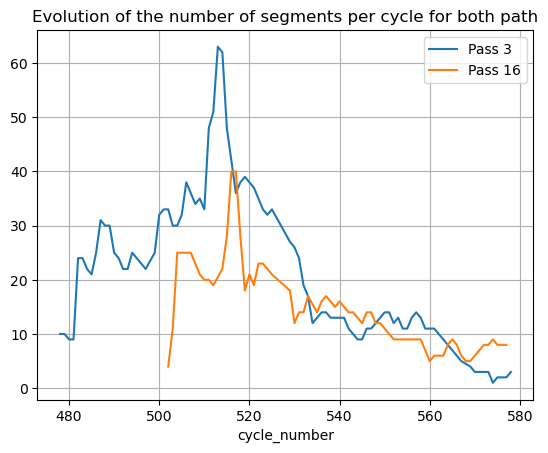

In [6]:
dff = df_stats.groupby(['pass_number','cycle_number']).drifter_id.count()
fig, ax = plt.subplots()
dff.loc[3].plot(label='Pass 3', ax=ax)
dff.loc[16].plot(label='Pass 16', ax=ax)
ax.legend()
ax.set_title('Evolution of the number of segments per cycle for both path')
ax.grid()

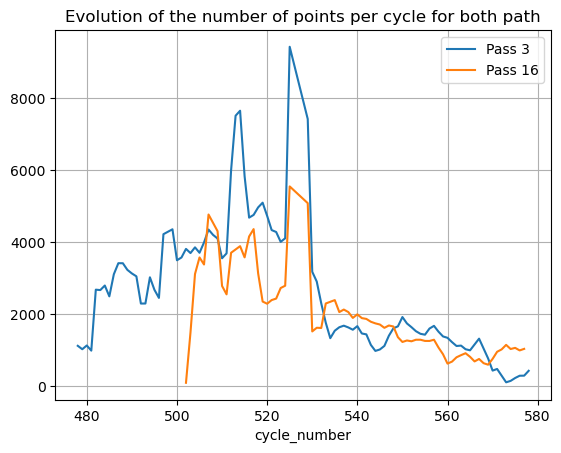

In [8]:
dff = df_stats.groupby(['pass_number','cycle_number']).point_number.sum()
fig, ax = plt.subplots()
dff.loc[3].plot(label='Pass 3', ax=ax)
dff.loc[16].plot(label='Pass 16', ax=ax)
ax.legend()
ax.set_title('Evolution of the number of points per cycle for both path')
ax.grid()

In [10]:
df_stats.point_number.sum()

383263

<Axes: >

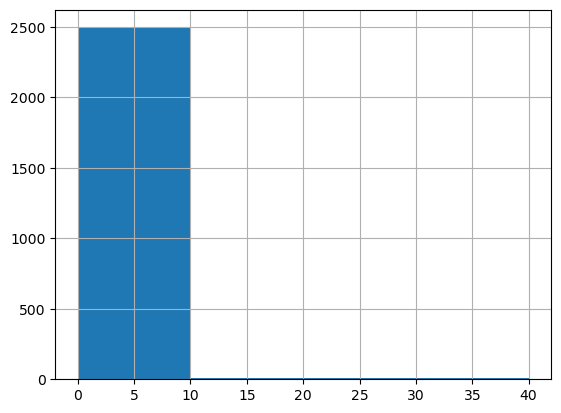

In [12]:
(df_stats.time_to_swot_min/pd.Timedelta('1min')).hist(bins = np.arange(0,50, 10))